In [18]:
import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

#### Importing the prediction in Ovarian spot transcriptomics and potting the AUROC

In [19]:
df_spatial_pred=pd.read_csv("/data/kumarr17/fixed_feature_cyt_result/ST_result/pred_cyt_on_spatial_spot_fixed_features_ov.csv")
df_spatial_pred['sample'] = df_spatial_pred['Unnamed: 0'].str.split('_').str[0]
response_map = {
    "GSM5708485": "Responder",
    "GSM5708486": "Responder",
    "GSM5708487": "Responder",
    "GSM5708488": "Responder",
    "GSM5708489": "Responder",
    "GSM5708490": "Responder",

    "GSM5708491": "NonResponder",
    "GSM5708492": "NonResponder",
    "GSM5708493": "NonResponder",
    "GSM5708494": "NonResponder",
    "GSM5708495": "NonResponder",
    "GSM5708496": "NonResponder"
}

df_spatial_pred["response"] = df_spatial_pred["sample"].map(response_map)
df_spatial_pred_v1=df_spatial_pred.set_index('Unnamed: 0')

In [20]:
df = df_spatial_pred_v1.copy()

# ----------------------------
# define X, y, groups
# ----------------------------
meta_cols = ["sample", "response"]

feature_cols = [
    c for c in df.columns
    if c not in meta_cols
]

X = df[feature_cols].copy()

y = df["response"].map({
    "Responder": 1,
    "NonResponder": 0
})

groups = df["sample"].values

# remove missing values
valid = y.notna() & X.notna().all(axis=1)

X = X.loc[valid]
y = y.loc[valid]
groups = groups[valid]
spot_ids = X.index

# ----------------------------
# Leave-one-sample-out CV
# ----------------------------
logo = LeaveOneGroupOut()

all_results = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):

    test_sample = np.unique(groups[test_idx])[0]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            solver="liblinear"
        )
    )

    model.fit(X.iloc[train_idx], y.iloc[train_idx])

    prob_responder = model.predict_proba(X.iloc[test_idx])[:, 1]
    pred_label = (prob_responder >= 0.5).astype(int)

    fold_df = pd.DataFrame({
        "spot_id": spot_ids[test_idx],
        "sample": groups[test_idx],
        "true_label": y.iloc[test_idx].values,
        "pred_prob_responder": prob_responder,
        "pred_label": pred_label
    })

    all_results.append(fold_df)

spot_pred_df = pd.concat(all_results, axis=0)

spot_pred_df["true_response"] = spot_pred_df["true_label"].map({
    1: "Responder",
    0: "NonResponder"
})

spot_pred_df["pred_response"] = spot_pred_df["pred_label"].map({
    1: "Responder",
    0: "NonResponder"
})


### Figure 6B

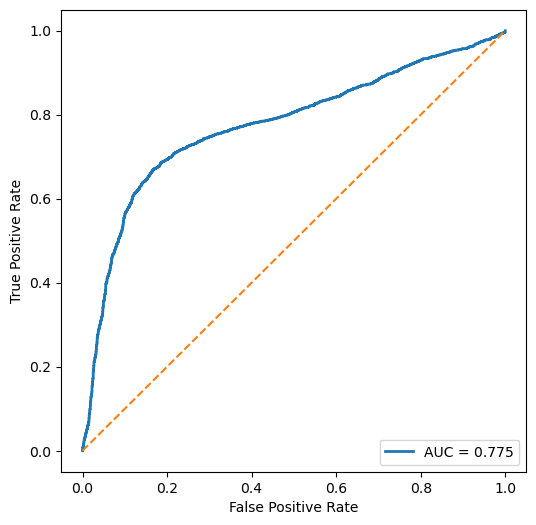

In [21]:
# ============================================================
# Calculate spot-level AUC
# ============================================================

spot_auc = roc_auc_score(
    spot_pred_df['true_label'],
    spot_pred_df['pred_prob_responder']
)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    spot_pred_df['true_label'],
    spot_pred_df['pred_prob_responder']
)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {spot_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# Save as SVG
#plt.savefig(
#    "/data/kumarr17/figures_to_upload/Figure5/spot_level_ROC_curve_OV.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()